In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import librosa
import wave
import os
import pylab
import numpy as np
from sklearn.model_selection import train_test_split
import torchvision
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.io import read_image
import torch.optim
import tqdm
import torch.nn.functional as F
import torchmetrics
from torchmetrics import Accuracy
from PIL import Image

In [2]:
def createSpectro(folder):          #Opening our audios and converting them to spectrograms
    for fold in os.listdir(folder):
        if not os.path.exists(str(str(folder) + '_img\\' + str(fold))):
            os.makedirs(str(str(folder) + '_img\\' + str(fold)))
        else:
            pass
        for fil in os.listdir(str(str(folder)+ '\\' + str(fold))):
            if not os.path.exists('music_dataset/Data/genres_original_img/'+str(fold) + '/' + (str(fil)[:-4]) + '.jpg'):
                try:
                    y, sr = (librosa.load(str(str(folder)+ '\\' + str(fold) + '\\' +str(fil))))
                    
                    pylab.axis('off')
                    pylab.axes([0., 0., 1., 1.], frameon=False, xticks=[], yticks=[])
                    S = librosa.feature.melspectrogram(y=y, sr=sr)
                    librosa.display.specshow(librosa.power_to_db(S, ref=np.max))
                    pylab.savefig('music_dataset/Data/genres_original_img/'+str(fold) + '/' + (str(fil)[:-4]) + '.jpg', bbox_inches=None, pad_inches=0)
                   
                    pylab.close()
                    #img = Image.open('music_dataset/Data/genres_original_img/'+str(fold) + '/' + (str(fil)[:-4]) + '.jpg').convert('L')
                    #img.save('music_dataset/Data/genres_original_img/'+str(fold) + '/' + (str(fil)[:-4]) + '.jpg')
                except:
                    print('This file was not accessible  :  music_dataset/Data/genres_original_img/'+str(fold) + '/' + (str(fil)[:-4]) + '.jpg')
            else:
                pass
            
createSpectro("music_dataset\Data\genres_original")




This file was not accessible  :  music_dataset/Data/genres_original_img/jazz/jazz.00054.jpg


C:\Users\dhruv\AppData\Local\Temp\ipykernel_4684\2828830832.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = (librosa.load(str(str(folder)+ '\\' + str(fold) + '\\' +str(fil))))
C:\Users\dhruv\anaconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [3]:
folder = "music_dataset\Data\images_original"
data_transform = transforms.Compose([transforms.ToTensor()])
    #transforms.Grayscale(num_output_channels=1),                              #tried making grayscale, didnt pan out
dataset = datasets.ImageFolder(root = folder, transform = data_transform)
train_data, test_data, valid_data= random_split(dataset, [0.7, 0.1, 0.2])  #Splitting into train/validation/tesst


In [4]:
print(dataset[0][0].shape)

torch.Size([3, 288, 432])


In [5]:
batch_size = 99

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)

valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=True)   # creating dataloaders

In [6]:
class CNN(nn.Module):             #defining our model and forward prop
    def __init__(self, in_channels, num_classes):
 
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)#these aren't used, but i have defined them while testing
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,padding=1)
        self.fc1 = nn.Linear(16 * 72 * 108, num_classes)

    def forward(self, x):
   
        x = F.relu(self.conv1(x))  
        x = self.pool(x)           
        x = F.relu(self.conv2(x))  
        x = self.pool(x)           
        #x = F.relu(self.conv3(x))
        #x = self.pool(x)
        #x = F.relu(self.conv4(x))
        #x = self.pool(x)
        x = x.reshape(x.shape[0], -1)  # Flattening the tensor
        x = self.fc1(x)           
        return x


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"          #allowing gpu use

model = CNN(in_channels=3, num_classes=10).to(device)
print(model)

CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=124416, out_features=10, bias=True)
)


In [8]:
# loss fn.
criterion = nn.CrossEntropyLoss()

# optimmizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
print(torch.cuda.is_available())

True


In [10]:
min_valid_loss = np.inf

num_epochs=25
for epoch in range(num_epochs):
# Iterate over training batches
    trainLoss = 0
    validLoss = 0
    for data, shouldBes in (tqdm.tqdm(train_loader)):         # Does the actual calc and optimizez - does fwd and backward
       
        data = data.to(device)
        shouldBes = shouldBes.to(device)
        Bes = model(data)
        loss = criterion(Bes, shouldBes)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        trainLoss += loss.item()

    for data, shouldBes in (tqdm.tqdm(valid_loader)):         #checks results against validation set to choose best model, and combat over fitting
        data = data.to(device)
        shouldBes = shouldBes.to(device)
        Bes = model(data)
        loss = criterion(Bes, shouldBes)
        validLoss += loss.item() * data.size(0)
    
        
    print(f'Epoch {epoch+1} / {num_epochs} Training loss: {trainLoss / len(train_loader)}  Validation loss: {validLoss / len(valid_loader)}')
    if min_valid_loss > validLoss:
        print(f'({min_valid_loss:.6f}--->{validLoss:.6f})  Model saved')
        min_valid_loss = validLoss
        torch.save(model.state_dict(), 'bestModel.pth')




100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.16it/s]


Epoch 1 / 25 Training loss: 6.840479135513306  Validation loss: 310.3409636815389
(inf--->931.022891)  Model saved


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.25it/s]


Epoch 2 / 25 Training loss: 3.793189138174057  Validation loss: 182.76721080144247
(931.022891--->548.301632)  Model saved


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.22it/s]


...

Epoch 23 / 25 Training loss: 0.38060880824923515  Validation loss: 88.27256194750468


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.12it/s]


Epoch 24 / 25 Training loss: 0.3085028026252985  Validation loss: 90.72283208370209


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.14it/s]

Epoch 25 / 25 Training loss: 0.22159335389733315  Validation loss: 89.22335131963094


In [11]:
model = CNN(in_channels=3, num_classes=10).to(device)
model.load_state_dict(torch.load('bestModel.pth'))

def accuracyCheck(model):            #to check accuracy
   
    acc = Accuracy(task="multiclass", num_classes=10)      
    acc = acc.to(device)
    
  
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device) 
            labels = labels.to(device)  
           
            outputs = model(images)             #run model on test data
            _, preds = torch.max(outputs, 1)
            acc(preds, labels)
            
    
    test_accuracy = acc.compute()
    print(f"Test accuracy: {test_accuracy}")       # we get accuracy
accuracyCheck(model)


Test accuracy: 0.5600000023841858


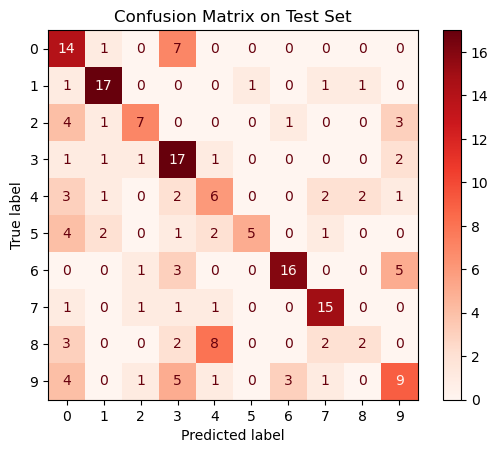

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.64      0.49        22
           1       0.74      0.81      0.77        21
           2       0.64      0.44      0.52        16
           3       0.45      0.74      0.56        23
           4       0.32      0.35      0.33        17
           5       0.83      0.33      0.48        15
           6       0.80      0.64      0.71        25
           7       0.68      0.79      0.73        19
           8       0.40      0.12      0.18        17
           9       0.45      0.38      0.41        24

    accuracy                           0.54       199
   macro avg       0.57      0.52      0.52       199
weighted avg       0.57      0.54      0.53       199



In [17]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():#checking against test set again, to generate confusion matrix and report
    for data, labels in test_loader:                                                         
        data = data.to(device)
        labels = labels.to(device)
        outputs = model(data)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

# Plotting the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title("Confusion Matrix on Test Set")
plt.show()


#Report
report = classification_report(all_labels, all_preds)
print("Classification Report:\n")
print(report)